In [1]:
import json
from transformers import AutoTokenizer
import torch as t
import os
from collections import defaultdict

/fs/nexus-scratch/scheng03/miniconda3/envs/refusal/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ntp_vector = t.load('../trained_vectors/gemma-2-2b-it/ntp_bsz6_lr1e-2_seed42/direction_8.pt', map_location='cpu')
reps_vector = t.load('../trained_vectors/gemma-2-2b-it/reps_bsz6_lr1e-2_ss2e-2_seed5/direction_1.pt', map_location='cpu')
dim_vector = t.load('../pipeline/runs/gemma-2-2b-it/direction_layer15_pos-1.pt', map_location='cpu')

In [3]:
l3_ntp_vector = t.load('../trained_vectors/Llama-3.2-3B-Instruct/ntp_bsz12_lr1e-2_seed5/direction_9.pt', map_location='cpu')
l3_reps_vector = t.load('../trained_vectors/Llama-3.2-3B-Instruct/reps_bsz12_lr1e-2_ss1e-5_seed5/direction_2.pt', map_location='cpu')
l3_dim_vector = t.load('../pipeline/runs/Llama-3.2-3B-Instruct/direction_layer12_pos-4.pt', map_location='cpu')

### check cosine similarity

In [4]:
print(t.cosine_similarity(ntp_vector, reps_vector, dim=0))
print(t.cosine_similarity(dim_vector, reps_vector, dim=0))
print(t.cosine_similarity(ntp_vector, dim_vector, dim=0))

tensor(0.4152)
tensor(0.3942, dtype=torch.float64)
tensor(0.3044, dtype=torch.float64)


In [5]:
print(t.cosine_similarity(l3_ntp_vector, l3_reps_vector, dim=0))
print(t.cosine_similarity(l3_dim_vector, l3_reps_vector, dim=0))
print(t.cosine_similarity(l3_ntp_vector, l3_dim_vector, dim=0))

tensor(0.1335)
tensor(0.0982, dtype=torch.float64)
tensor(0.3323, dtype=torch.float64)


In [7]:
dim_rtol01 = t.load('../vectors/gemma-2-2b-it/dim_logit_rtol=0.1.pt')['direction']
ntp_rtol01 = t.load('../vectors/gemma-2-2b-it/ntp_logit_rtol=0.1.pt')['direction']
po_rtol01 = t.load('../vectors/gemma-2-2b-it/reps_logit_rtol=0.1.pt')['direction']


In [8]:
print(t.cosine_similarity(dim_rtol01, po_rtol01, dim=0))
print(t.cosine_similarity(dim_rtol01, ntp_rtol01, dim=0))
print(t.cosine_similarity(ntp_rtol01, po_rtol01, dim=0))

tensor(0.4133)
tensor(0.3046)
tensor(0.4006)


In [ ]:
def overlap(enc_1, enc_2):
    overlap = t.logical_and(enc_1, enc_2)
    num_edges_1 = enc_1.sum()
    num_edges_2 = enc_2.sum()
    return overlap.sum()/num_edges_1, overlap.sum()/num_edges_2

def iou(enc_1, enc_2):
    intersection = t.logical_and(enc_1, enc_2).sum()
    union = t.logical_or(enc_1, enc_2).sum()
    return intersection / union

def check_similarities(vs):
    vs_nonzero = vs == 0
    N = len(vs_nonzero)
    sim_matrix = t.zeros(N, N)
    for i in range(N):
        for j in range(N):
            sim_matrix[i, j] = iou(vs_nonzero[i], vs_nonzero[j])
    return sim_matrix

In [18]:
paths = [
    'dim_logit_rtol=0.3.pt',
    'dim_logit_rtol=1.pt',
    'ntp_logit_rtol=0.3.pt',
    'ntp_logit_rtol=1.pt',
    'reps_logit_rtol=0.3.pt',
    'reps_logit_rtol=1.pt',
]
vs = [t.load(os.path.join('../vectors/gemma-2-2b-it', p))['direction'] for p in paths]
V = t.stack(vs)
print((V==0).sum(dim=-1))
print(V.norm(dim=-1))

V_u = V / V.norm(dim=-1, keepdim=True)
V_u @ V_u.T

tensor([ 764, 1928,  628, 1722,  741, 1863])
tensor([115.9017, 115.9017, 115.9017, 115.9017, 115.9017, 115.9017])


tensor([[1.0000, 0.5920, 0.3027, 0.3218, 0.4317, 0.3332],
        [0.5920, 1.0000, 0.2287, 0.3269, 0.3624, 0.3711],
        [0.3027, 0.2287, 1.0000, 0.6402, 0.3745, 0.2601],
        [0.3218, 0.3269, 0.6402, 1.0000, 0.3532, 0.3119],
        [0.4317, 0.3624, 0.3745, 0.3532, 1.0000, 0.6470],
        [0.3332, 0.3711, 0.2601, 0.3119, 0.6470, 1.0000]])

Want to check the similarities of vectors post sparsification

In [64]:
sparse_paths_r01 = [
    # 'dim_logit_base_harmless_rtol=0.1.pt',
    'dim_logit_steer_harmless_rtol=0.1.pt',
    # 'ntp_dkl0_steer_harmless_rtol=0.1.pt',
    'ntp_dkl0_steer_harmful_rtol=0.1.pt',
    'reps_logit_steer_harmless_rtol=0.1.pt',
    # 'reps_logit_steer_harmful_rtol=0.1.pt',
]
sparse_paths_r03 = [
    # 'dim_logit_base_harmless_rtol=0.3.pt',
    'dim_logit_steer_harmless_rtol=0.3.pt',
    # 'ntp_dkl0_steer_harmless_rtol=0.3.pt',
    'ntp_dkl0_steer_harmful_rtol=0.3.pt',
    'reps_logit_steer_harmless_rtol=0.3.pt',
    # 'reps_logit_steer_harmful_rtol=0.3.pt',
]
orig_paths = [
    "../pipeline/runs/gemma-2-2b-it/direction_layer15_pos-1.pt",
    "../trained_vectors/gemma-2-2b-it/ntp_bsz6_lr1e-2_seed42/direction_8.pt",
    "../trained_vectors/gemma-2-2b-it/reps_bsz6_lr1e-2_ss2e-2_seed5/direction_1.pt",
]

In [65]:
vs_sparse_r01 = [t.load(os.path.join('../vectors/gemma-2-2b-it', p))['direction'] for p in sparse_paths_r01]
V_r01 = t.stack(vs_sparse_r01)
vs_sparse_r03 = [t.load(os.path.join('../vectors/gemma-2-2b-it', p))['direction'] for p in sparse_paths_r03]
V_r03 = t.stack(vs_sparse_r03)
vs_orig = [t.load(p, map_location='cpu') for p in orig_paths]
V_orig = t.stack(vs_orig)


In [66]:
# compare sparse vector similarity to original vector similarity
V_r01_unit = V_r01 / V_r01.norm(dim=-1, keepdim=True)
V_r03_unit = V_r03 / V_r03.norm(dim=-1, keepdim=True)
V_orig_unit = V_orig / V_orig.norm(dim=-1, keepdim=True)

In [67]:
S_r01 = V_r01_unit @ V_r01_unit.T
S_r03 = V_r03_unit @ V_r03_unit.T
S_orig = V_orig_unit @ V_orig_unit.T
sim_dim_ntp = [S_orig[0,1], S_r01[0,1], S_r03[0,1]]
sim_dim_reps = [S_orig[0,2], S_r01[0,2], S_r03[0,2]]
sim_ntp_reps = [S_orig[1,2], S_r01[1,2], S_r03[0,2]]
x = ['0, 0.1, 0.3']
xs = ['DIM | NTP', 'DIM | RePS', 'NTP | RePS']

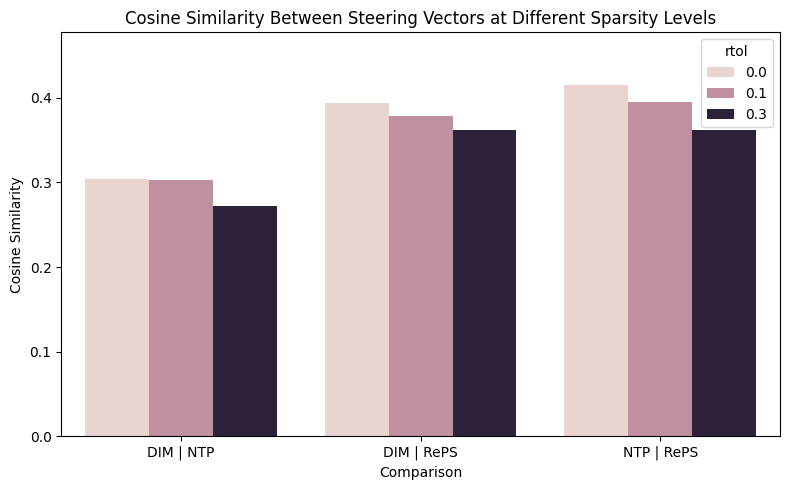

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


rtol_labels = [0, 0.1, 0.3]
comparisons = xs  # ['DIM | NTP', 'DIM | RePS', 'NTP | RePS']
sims = [sim_dim_ntp, sim_dim_reps, sim_ntp_reps]

records = []
for comp, sim in zip(comparisons, sims):
    reordered = [sim[0].item(), sim[1].item(), sim[2].item()]  # 0, 0.1, 0.3
    for rtol, val in zip(rtol_labels, reordered):
        records.append({'Comparison': comp, 'rtol': rtol, 'Cosine Similarity': val})

df = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x='Comparison', y='Cosine Similarity', hue='rtol', ax=ax)
ax.set_title('Cosine Similarity Between Steering Vectors at Different Sparsity Levels')
ax.set_ylim(0, max(df['Cosine Similarity']) * 1.15)
ax.legend(title='rtol')
plt.tight_layout()
plt.savefig('sparse_sim.png')
plt.show()


In [37]:
train_paths = [
    'pipeline/runs/gemma-2-2b-it/direction_layer15_pos-1.pt',
    'trained_vectors/gemma-2-2b-it/ntp_bsz6_lr1e-2_seed42/direction_8.pt',
    'trained_vectors/gemma-2-2b-it/reps_bsz6_lr1e-2_ss2e-2_seed5/direction_1.pt',
]

In [39]:
vs_train = [t.load(p, map_location='cpu') for p in train_paths]
V_train = t.stack(vs_train)

In [41]:
V_sparse_unit = V_sparse / V_sparse.norm(dim=-1).unsqueeze(1)
print(V_sparse_unit @ V_sparse_unit.T)

V_train_unit = V_train / V_train.norm(dim=-1).unsqueeze(1)
print(V_train_unit @ V_train_unit.T)

V_all = t.cat((V_sparse, V_train))
V_all_unit = V_all / V_all.norm(dim=-1).unsqueeze(1)
print(V_all_unit @ V_all_unit.T)

tensor([[1.0000, 0.8238, 0.3557, 0.2778, 0.3851, 0.3780],
        [0.8238, 1.0000, 0.3806, 0.2716, 0.3618, 0.3489],
        [0.3557, 0.3806, 1.0000, 0.5880, 0.3191, 0.2777],
        [0.2778, 0.2716, 0.5880, 1.0000, 0.3673, 0.3478],
        [0.3851, 0.3618, 0.3191, 0.3673, 1.0000, 0.7351],
        [0.3780, 0.3489, 0.2777, 0.3478, 0.7351, 1.0000]])
tensor([[1.0000, 0.3044, 0.3942],
        [0.3044, 1.0000, 0.4152],
        [0.3942, 0.4152, 1.0000]], dtype=torch.float64)
tensor([[1.0000, 0.8238, 0.3557, 0.2778, 0.3851, 0.3780, 0.8755, 0.2850, 0.4134],
        [0.8238, 1.0000, 0.3806, 0.2716, 0.3618, 0.3489, 0.8886, 0.2797, 0.3772],
        [0.3557, 0.3806, 1.0000, 0.5880, 0.3191, 0.2777, 0.3618, 0.6559, 0.3173],
        [0.2778, 0.2716, 0.5880, 1.0000, 0.3673, 0.3478, 0.2973, 0.8809, 0.3984],
        [0.3851, 0.3618, 0.3191, 0.3673, 1.0000, 0.7351, 0.3608, 0.3808, 0.8694],
        [0.3780, 0.3489, 0.2777, 0.3478, 0.7351, 1.0000, 0.3592, 0.3461, 0.8619],
        [0.8755, 0.8886, 0.3618, 0.

In [ ]:
V_sparse_mask = V_sparse == 0
print(V_sparse_mask.sum(dim=-1))

sim_matrix = t.zeros(len(V_sparse_mask), len(V_sparse_mask))
for i in range(len(sim_matrix)):
    for j in range(len(sim_matrix)):
        sim_matrix[i, j] = overlap(V_sparse_mask[i], V_sparse_mask[j])[0]
print(sim_matrix)

tensor([908, 654, 732, 639, 634, 699])
tensor([[1.0000, 0.2896, 0.4020, 0.5308, 0.3436, 0.3139],
        [0.4021, 1.0000, 0.3685, 0.2951, 0.2890, 0.4006],
        [0.4986, 0.3292, 1.0000, 0.3661, 0.3306, 0.3511],
        [0.7543, 0.3020, 0.4194, 1.0000, 0.4022, 0.3036],
        [0.4921, 0.2981, 0.3817, 0.4054, 1.0000, 0.2760],
        [0.4077, 0.3748, 0.3677, 0.2775, 0.2504, 1.0000]])
